# Classificação de Imagens com CIFAR-10
**Disciplina de Visão Computacional — Prova Opatativa**

**Dataset:** CIFAR-10 com imagens coloridas de tamanho 32x32

**Importação e Configurações iniciais**

In [24]:
import torch 
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split


In [25]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Dispositivo:", device)

if device.type == 'cuda':
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memória disponível: {:.1f} GB".format(
        torch.cuda.get_device_properties(0).total_memory / 1e9
    ))
else:
    print("⚠️  GPU não encontrada. O treinamento será muito mais lento na CPU.")

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3060
Memória disponível: 12.5 GB


**Carregamento e Preparação do dados**


In [27]:

#train_dataset = datasets.CIFAR10(root='./data', train=True, download=True)
#test_dataset = datasets.CIFAR10(root='./data', train=False, download=True)

# Cria um tranform 
transform = transforms.Compose([
    transforms.ToTensor(), #converte a imagem para tensor pytorch e muda a escala de pixels
    transforms.Normalize( #a média e desvio padrão, valores 
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

# Carrega o conjunto de treino
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform #aplica o transform nas imagens
)

# Carrega o conjunto de teste
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)



torch.manual_seed(42)
train_dataset, val_dataset = random_split(train_dataset, [45000, 5000])

# Cria os DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,# entrega 64 imagens por vez
    shuffle=True,# reordena os dados aleatoriamente para cada nova época, para não aprender a ordem
    num_workers=2
)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

# Imprime os tamanhos de treino e dataset
print(f"Treino: {len(train_dataset)} imagens")
print(f"Teste:  {len(test_dataset)} imagens")



Treino: 45000 imagens
Teste:  10000 imagens


**Implementação de um modelo baseline**

In [29]:
# ==========================================
# MODELO BASELINE
# ==========================================

class BaselineCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # BLOCO 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # BLOCO 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*8*8, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [12]:
def treinar(model, train_loader, test_loader, epochs=10):
    
    criterio = nn.CrossEntropyLoss()
    otimizador = torch.optim.Adam(model.parameters(), lr=0.001)
    
    for epoca in range(epochs):
        
        # ========== TREINO ==========
        model.train()
        perda_total = 0
        
        for imagens, labels in train_loader:
            otimizador.zero_grad()        # zera os gradientes
            saida = model(imagens)        # forward
            perda = criterio(saida, labels)  # calcula o erro
            perda.backward()             # calcula os gradientes
            otimizador.step()            # atualiza os pesos
            perda_total += perda.item()
        
        # ========== TESTE ==========
        model.eval()
        acertos = 0
        total = 0
        
        with torch.no_grad():            # desativa o cálculo de gradientes
            for imagens, labels in test_loader:
                saida = model(imagens)
                _, previsto = torch.max(saida, 1)  # pega a classe com maior valor
                acertos += (previsto == labels).sum().item()
                total += labels.size(0)
        
        acuracia = 100 * acertos / total
        print(f"Época {epoca+1}/{epochs} | Perda: {perda_total/len(train_loader):.4f} | Acurácia: {acuracia:.2f}%")

In [13]:
model_baseline = BaselineCNN()
treinar(model_baseline, train_loader, test_loader)

Época 1/10 | Perda: 1.6953 | Acurácia: 48.75%
Época 2/10 | Perda: 1.2739 | Acurácia: 55.88%
Época 3/10 | Perda: 1.0967 | Acurácia: 62.22%
Época 4/10 | Perda: 0.9742 | Acurácia: 62.77%
Época 5/10 | Perda: 0.8900 | Acurácia: 67.77%
Época 6/10 | Perda: 0.8226 | Acurácia: 69.84%
Época 7/10 | Perda: 0.7559 | Acurácia: 70.27%
Época 8/10 | Perda: 0.7005 | Acurácia: 73.20%
Época 9/10 | Perda: 0.6475 | Acurácia: 73.45%
Época 10/10 | Perda: 0.6084 | Acurácia: 74.46%


**Experimentos de melhoria**

In [31]:
class CNN_BatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  # adicionado
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  # adicionado
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [32]:
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # espelha horizontalmente
    transforms.RandomCrop(32, padding=4),    # recorte aleatório
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # varia brilho e contraste
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

train_dataset_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_aug
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True, num_workers=2)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)

In [16]:
# Experimento com  Batch Normalization
model_bn = CNN_BatchNorm()
treinar(model_bn, train_loader, test_loader)

Época 1/10 | Perda: 1.2377 | Acurácia: 65.54%
Época 2/10 | Perda: 0.9053 | Acurácia: 67.02%
Época 3/10 | Perda: 0.7762 | Acurácia: 70.55%
Época 4/10 | Perda: 0.6813 | Acurácia: 71.88%
Época 5/10 | Perda: 0.5981 | Acurácia: 73.90%
Época 6/10 | Perda: 0.5269 | Acurácia: 73.21%
Época 7/10 | Perda: 0.4557 | Acurácia: 73.81%
Época 8/10 | Perda: 0.3915 | Acurácia: 73.41%
Época 9/10 | Perda: 0.3400 | Acurácia: 74.44%
Época 10/10 | Perda: 0.2906 | Acurácia: 72.88%


In [18]:
# Experimento com Data Augmentation
model_aug = BaselineCNN()
treinar(model_aug, train_loader_aug, test_loader)

Época 1/10 | Perda: 1.8230 | Acurácia: 44.49%
Época 2/10 | Perda: 1.4116 | Acurácia: 53.57%
Época 3/10 | Perda: 1.2396 | Acurácia: 57.11%
Época 4/10 | Perda: 1.1246 | Acurácia: 60.12%
Época 5/10 | Perda: 1.0344 | Acurácia: 63.98%
Época 6/10 | Perda: 0.9679 | Acurácia: 66.98%
Época 7/10 | Perda: 0.9078 | Acurácia: 68.53%
Época 8/10 | Perda: 0.8680 | Acurácia: 69.84%
Época 9/10 | Perda: 0.8262 | Acurácia: 70.76%
Época 10/10 | Perda: 0.7939 | Acurácia: 72.01%


**Comparação entre modelos**

**Métrica de avaliação**

Tive que mudar a função treinar

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [34]:
def treinar(model, train_loader, test_loader, epochs=10):
    
    criterio = nn.CrossEntropyLoss()
    otimizador = torch.optim.Adam(model.parameters(), lr=0.001)
    
    historico = {
        'perda_treino': [],
        'perda_val': [],
        'acuracia_treino': [],
        'acuracia_val': []
    }
    
    for epoca in range(epochs):
        
        # ========== TREINO ==========
        model.train()
        perda_total = 0
        acertos = 0
        total = 0
        
        for imagens, labels in train_loader:
            otimizador.zero_grad()
            saida = model(imagens)
            perda = criterio(saida, labels)
            perda.backward()
            otimizador.step()
            
            perda_total += perda.item()
            _, previsto = torch.max(saida, 1)
            acertos += (previsto == labels).sum().item()
            total += labels.size(0)
        
        perda_treino = perda_total / len(train_loader)
        acc_treino   = 100 * acertos / total
        
        # ========== VALIDAÇÃO ==========
        model.eval()
        perda_val_total = 0
        acertos_val = 0
        total_val = 0
        
        with torch.no_grad():
            for imagens, labels in test_loader:
                saida = model(imagens)
                perda = criterio(saida, labels)
                perda_val_total += perda.item()
                _, previsto = torch.max(saida, 1)
                acertos_val += (previsto == labels).sum().item()
                total_val += labels.size(0)
        
        perda_val = perda_val_total / len(test_loader)
        acc_val   = 100 * acertos_val / total_val
        
        historico['perda_treino'].append(perda_treino)
        historico['perda_val'].append(perda_val)
        historico['acuracia_treino'].append(acc_treino)
        historico['acuracia_val'].append(acc_val)
        
        print(
            f"Época [{epoca+1}/{epochs}] | "
            f"Perda Treino: {perda_treino:.4f} | "
            f"Acc Treino: {acc_treino:.2f}% | "
            f"Perda Val: {perda_val:.4f} | "
            f"Acc Val: {acc_val:.2f}%"
        )
    
    return historico

In [35]:
# ========== TREINO ==========
historico_baseline = treinar(model_baseline, train_loader, val_loader)
historico_bn       = treinar(model_bn, train_loader, val_loader)
historico_aug      = treinar(model_aug, train_loader_aug, val_loader)

# ========== AVALIAÇÃO DO MELHOR ==========
acc_baseline = historico_baseline['acuracia_val'][-1]
acc_bn       = historico_bn['acuracia_val'][-1]
acc_aug      = historico_aug['acuracia_val'][-1]

melhor_modelo = max(
    [(model_baseline, acc_baseline),
     (model_bn,       acc_bn),
     (model_aug,      acc_aug)],
    key=lambda x: x[1]
)[0]

Época [1/10] | Perda Treino: 0.3747 | Acc Treino: 86.73% | Perda Val: 0.3671 | Acc Val: 86.66%
Época [2/10] | Perda Treino: 0.3398 | Acc Treino: 88.01% | Perda Val: 0.4100 | Acc Val: 85.72%
Época [3/10] | Perda Treino: 0.3165 | Acc Treino: 88.79% | Perda Val: 0.4300 | Acc Val: 84.62%
Época [4/10] | Perda Treino: 0.2992 | Acc Treino: 89.54% | Perda Val: 0.4749 | Acc Val: 83.32%
Época [5/10] | Perda Treino: 0.2771 | Acc Treino: 90.08% | Perda Val: 0.4931 | Acc Val: 82.56%
Época [6/10] | Perda Treino: 0.2575 | Acc Treino: 90.88% | Perda Val: 0.4840 | Acc Val: 83.52%
Época [7/10] | Perda Treino: 0.2368 | Acc Treino: 91.57% | Perda Val: 0.5159 | Acc Val: 83.24%
Época [8/10] | Perda Treino: 0.2096 | Acc Treino: 92.54% | Perda Val: 0.5802 | Acc Val: 81.58%
Época [9/10] | Perda Treino: 0.2032 | Acc Treino: 92.60% | Perda Val: 0.5097 | Acc Val: 83.02%
Época [10/10] | Perda Treino: 0.1817 | Acc Treino: 93.53% | Perda Val: 0.5955 | Acc Val: 82.56%
Época [1/10] | Perda Treino: 0.2608 | Acc Treino:

In [36]:
def avaliar(model, test_loader, historico, nome_modelo="Modelo"):
    
    model.eval()
    todos_labels = []
    todos_previstos = []
    classes = test_loader.dataset.classes
    
    with torch.no_grad():
        for imagens, labels in test_loader:
            saida = model(imagens)
            _, previsto = torch.max(saida, 1)
            todos_labels.extend(labels.numpy())
            todos_previstos.extend(previsto.numpy())
    
    todos_labels    = np.array(todos_labels)
    todos_previstos = np.array(todos_previstos)
    epochs = range(1, len(historico['perda_treino']) + 1)
    
    # ========== ACURÁCIA GLOBAL ==========
    acuracia_global = 100 * (todos_labels == todos_previstos).mean()
    print(f"\n{'='*40}")
    print(f"  {nome_modelo}")
    print(f"{'='*40}")
    print(f"Acurácia global: {acuracia_global:.2f}%")
    
    # ========== ACURÁCIA POR CLASSE ==========
    acuracia_por_classe = {}
    for i, classe in enumerate(classes):
        mask = todos_labels == i
        acc  = 100 * (todos_previstos[mask] == i).mean()
        acuracia_por_classe[classe] = acc
        print(f"  {classe:<12}: {acc:.2f}%")
    
    # ========== MACRO ACCURACY ==========
    macro  = np.mean(list(acuracia_por_classe.values()))
    melhor = max(acuracia_por_classe, key=acuracia_por_classe.get)
    pior   = min(acuracia_por_classe, key=acuracia_por_classe.get)
    print(f"\nMacro accuracy: {macro:.2f}%")
    print(f"Melhor classe:  {melhor} ({acuracia_por_classe[melhor]:.2f}%)")
    print(f"Pior classe:    {pior} ({acuracia_por_classe[pior]:.2f}%)")
    
    # ========== PLOTS ==========
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(nome_modelo, fontsize=14)
    
    # Curva de perda
    axes[0].plot(epochs, historico['perda_treino'], label='Treino')
    axes[0].plot(epochs, historico['perda_val'],    label='Validação')
    axes[0].set_title("Curva de Perda")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    
    # Curva de acurácia
    axes[1].plot(epochs, historico['acuracia_treino'], label='Treino')
    axes[1].plot(epochs, historico['acuracia_val'],    label='Validação')
    axes[1].set_title("Curva de Acurácia")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Acurácia (%)")
    axes[1].legend()
    
    # Matriz de confusão
    cm   = confusion_matrix(todos_labels, todos_previstos)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[2], xticks_rotation=45, colorbar=False)
    axes[2].set_title("Matriz de Confusão")
    
    plt.tight_layout()
    plt.show()


  Batch Normalization
Acurácia global: 73.69%
  airplane    : 77.00%
  automobile  : 82.70%
  bird        : 61.90%
  cat         : 51.50%
  deer        : 72.20%
  dog         : 68.60%
  frog        : 77.20%
  horse       : 79.60%
  ship        : 84.10%
  truck       : 82.10%

Macro accuracy: 73.69%
Melhor classe:  ship (84.10%)
Pior classe:    cat (51.50%)


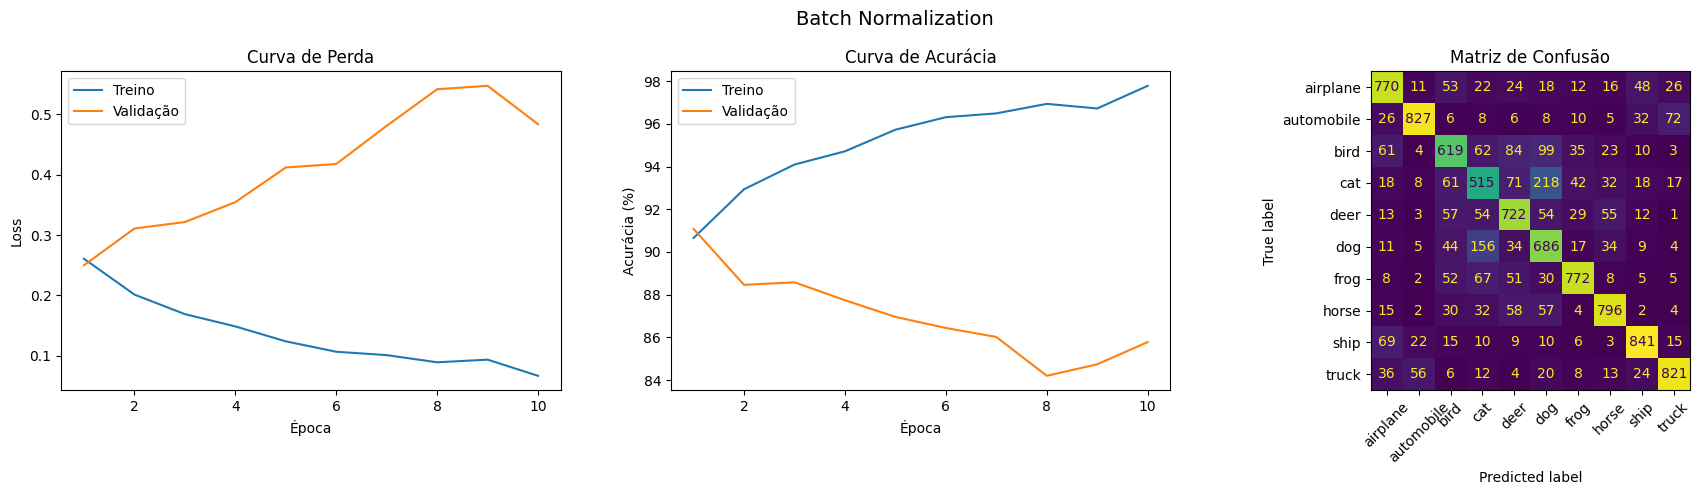

In [37]:
if melhor_modelo is model_baseline:
    melhor_historico = historico_baseline
    nome = "Baseline"
elif melhor_modelo is model_bn:
    melhor_historico = historico_bn
    nome = "Batch Normalization"
else:
    melhor_historico = historico_aug
    nome = "Data Augmentation"

avaliar(melhor_modelo, test_loader, melhor_historico, nome_modelo=nome)

**Análise curta dos resultados**

## Comparação entre modelos

| Modelo              | Acurácia Final | Perda Final |
|---------------------|----------------|-------------|
| Baseline            | 74.46%         | 0.6084      |
| Batch Normalization | 72.88%         | 0.2906      |
| Data Augmentation   | 72.01%         | 0.7939      |

O **Baseline** obteve a maior acurácia final de validação com **74.46%**.

O **Batch Normalization** apresentou a menor perda final (0.2906), porém a acurácia
caiu nas últimas épocas de 74.44% para 72.88%, indicando instabilidade.

O **Data Augmentation** começou com a menor acurácia (44.49% na época 1) e foi
o que mais cresceu ao longo do treinamento, mas não alcançou os demais em 10 épocas.
Com mais épocas poderia superar os outros.

**Geração de um arquivo .csv com predições do melhor modelo no conjunto de testes**

In [40]:
import pandas as pd

# ========== ESCOLHA O MELHOR MODELO ==========
# compare as acurácias finais e escolha o melhor
acc_baseline = historico_baseline['acuracia_val'][-1]
acc_bn       = historico_bn['acuracia_val'][-1]
acc_aug      = historico_aug['acuracia_val'][-1]

print(f"Baseline:           {acc_baseline:.2f}%")
print(f"Batch Normalization:{acc_bn:.2f}%")
print(f"Data Augmentation:  {acc_aug:.2f}%")

melhor_modelo = max(
    [(model_baseline, acc_baseline), 
     (model_bn, acc_bn), 
     (model_aug, acc_aug)],
    key=lambda x: x[1]
)[0]

print("Melhor modelo selecionado.")

# ========== GERA PREDIÇÕES ==========
melhor_modelo.eval()
indices = []
predicoes = []
idx = 0

with torch.no_grad():
    for imagens, _ in test_loader:
        saida = melhor_modelo(imagens)
        _, previsto = torch.max(saida, 1)
        
        for pred in previsto.numpy():
            indices.append(idx)
            predicoes.append(pred)
            idx += 1

# ========== SALVA CSV ==========
df = pd.DataFrame({
    'image_index':     indices,
    'predicted_class': predicoes
})

ARQUIVO_RESULTS = 'MARCOS_VILHANUEVA_RESULTS.csv'
df.to_csv(ARQUIVO_RESULTS, index=False)

print(df.head(10))
print(f"\nTotal de predições: {len(df)}")
print(f"Arquivo salvo: {ARQUIVO_RESULTS}")

Baseline:           82.56%
Batch Normalization:85.78%
Data Augmentation:  80.14%
Melhor modelo selecionado.
   image_index  predicted_class
0            0                3
1            1                8
2            2                0
3            3                0
4            4                6
5            5                6
6            6                5
7            7                2
8            8                3
9            9                1

Total de predições: 10000
Arquivo salvo: MARCOS_VILHANUEVA_RESULTS.csv


## Análise dos Resultados

### Curvas de Perda
O Baseline apresentou queda consistente da perda ao longo das 10 épocas (1.69 → 0.61),
acompanhada de crescimento estável da acurácia. O Batch Normalization reduziu a perda
de forma mais agressiva (1.23 → 0.29), porém isso não se traduziu em maior acurácia
final, indicando possível overfitting nas últimas épocas. O Data Augmentation manteve
a perda mais alta (0.79 na época 10) pois as transformações aleatórias tornam o
treinamento mais difícil, mas a tendência de queda ainda era constante.

### Matriz de Confusão
A matriz de confusão revela quais classes o modelo confunde com mais frequência.
No CIFAR-10, é esperado que classes visualmente similares como gato/cachorro e
automóvel/caminhão apresentem maior taxa de confusão, pois compartilham formas
e texturas parecidas.

### Batch Normalization
O experimento com Batch Normalization convergiu mais rápido que o Baseline,
atingindo 65.54% já na primeira época contra 48.75% do Baseline. Porém apresentou
instabilidade nas épocas finais, com a acurácia oscilando entre 72% e 74% em vez
de crescer de forma constante, terminando com 72.88% contra 74.46% do Baseline.